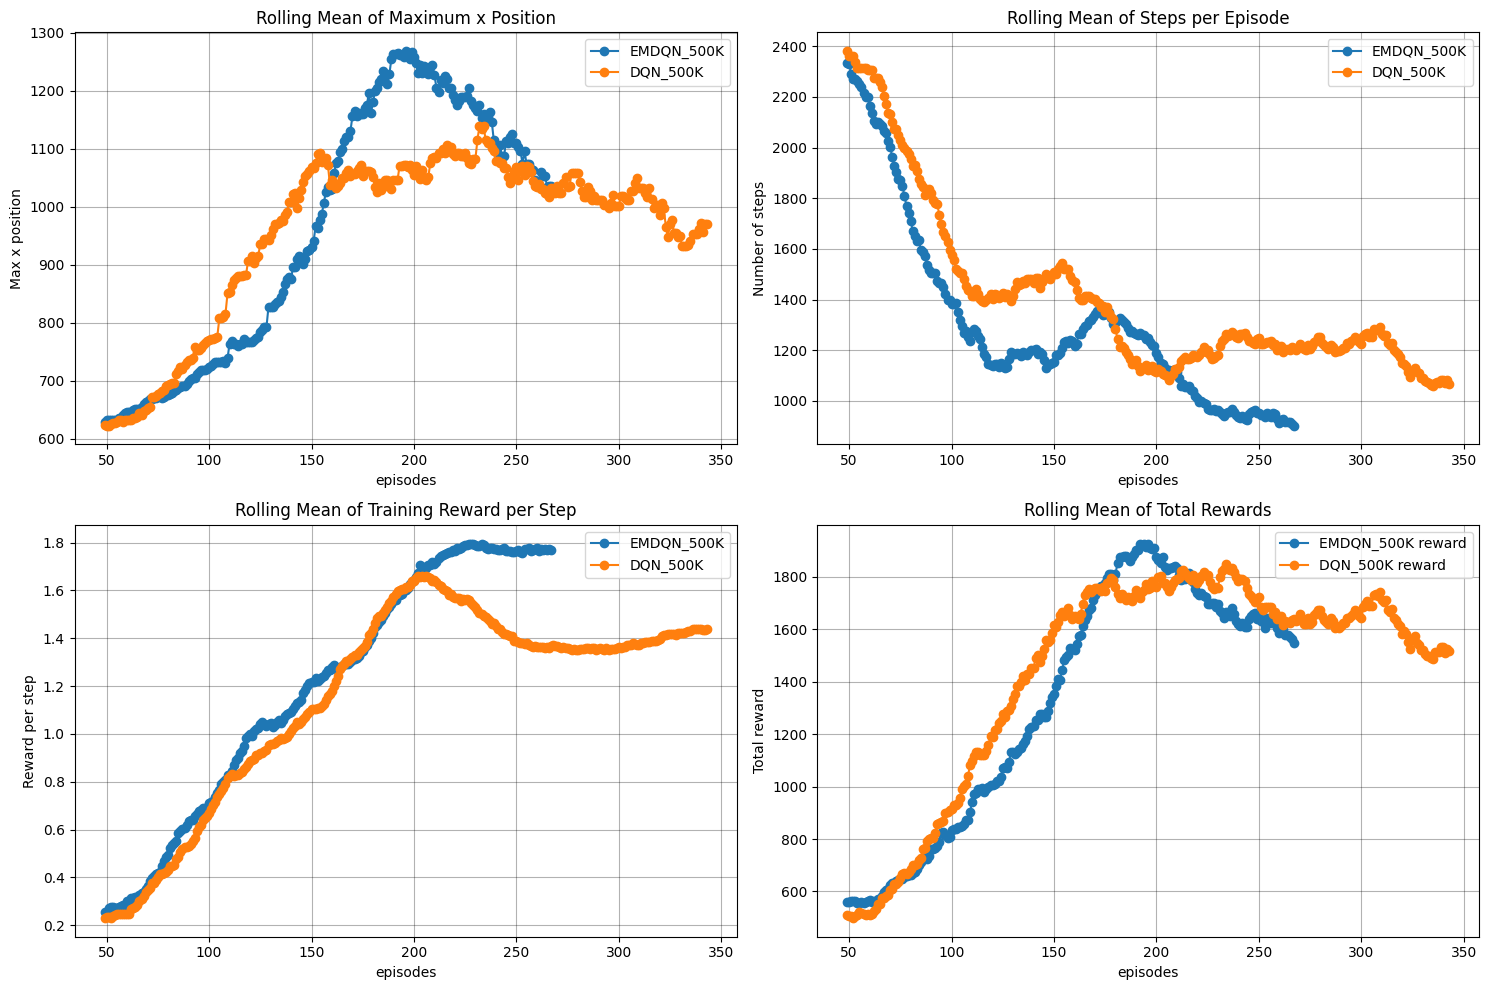

In [359]:
import matplotlib.pyplot as plt
import pandas as pd

# dqn = pd.read_csv("dqn_final_v0/train_metrics.csv", index_col=0)
# emdqn = pd.read_csv("emdqn_final_v0/train_metrics.csv", index_col=0)
emdqn_long = pd.read_csv("emdqn_no_skipping_short_ep_long_v0/train_metrics.csv", index_col=0)
dqn_long = pd.read_csv("dqn_no_skipping_short_ep_long_v0/train_metrics.csv", index_col=0)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

window_size = 50

for name, df in [
    # ("dqn", dqn),
    # ("emdqn", emdqn),
    ("emdqn_500k", emdqn_long),
    ("dqn_500k", dqn_long)
]:
    # Plot max x position
    axs[0, 0].plot(df.ep_max_x_pos.rolling(window_size).mean(), marker="o", label=name.upper())
    axs[0, 0].set_ylabel("Max x position")
    axs[0, 0].set_title("Rolling Mean of Maximum x Position")
    axs[0, 0].legend()

    # Plot number of steps
    axs[0, 1].plot(df.ep_steps.rolling(window_size).mean(), marker="o", label=name.upper())
    axs[0, 1].set_ylabel("Number of steps")
    axs[0, 1].set_title("Rolling Mean of Steps per Episode")
    axs[0, 1].legend()

    # Plot train reward per step
    axs[1, 0].plot(df.ep_train_reward_per_step.rolling(window_size).mean(), marker="o", label=name.upper())
    axs[1, 0].set_ylabel("Reward per step")
    axs[1, 0].set_title("Rolling Mean of Training Reward per Step")
    axs[1, 0].legend()

    # Plot total rewards
    axs[1, 1].plot(df.ep_total_reward.rolling(window_size).mean(), label=f"{name.upper()} reward", marker="o")
    axs[1, 1].set_ylabel("Total reward")
    axs[1, 1].set_title("Rolling Mean of Total Rewards")
    axs[1, 1].legend()

for i in range(2):
    for j in range(2):
        axs[i, j].grid()
        axs[i, j].set_xlabel("episodes")

plt.tight_layout()
plt.show()

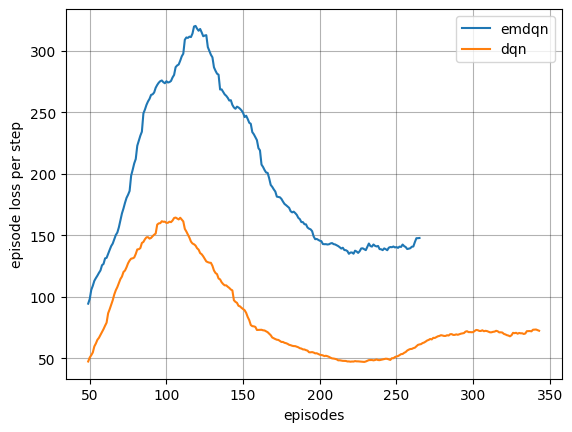

In [357]:
plt.plot(emdqn_long.ep_train_loss_per_step.rolling(window_size).mean(), label="emdqn")
plt.plot(dqn_long.ep_train_loss_per_step.rolling(window_size).mean(), label="dqn")
plt.xlabel("episodes")
plt.ylabel("episode loss per step")
plt.legend()
plt.grid()